# Hoja de trabajo 2

## Task 2 y 3

### Integrantes
* Sergio Orellana 221122
* Rodrigo Mansilla 22611
* Ricardo Chuy 221007

## Simulador de *k-armed bandit*

El notebook implementa el entorno, las estrategias, los experimentos y las visualizaciones. Los comentarios breves indican la función de cada parte.

In [ ]:
import numpy as np

import matplotlib.pyplot as plt

from copy import deepcopy

### 1. Entorno

La clase representa las `k` acciones, sus valores reales ocultos y la recompensa obtenida. En modo no estacionario debe modificar esos valores cada cierto número de pasos.

In [9]:
class KArmedBandit:
    def __init__(self, k=10, stationary=True, perturb_every=100, perturb_scale=0.01, seed=None):
        # Guarda la configuración y crea un generador aleatorio reproducible.
        self.k = k
        self.stationary = stationary
        self.perturb_every = perturb_every
        self.perturb_scale = perturb_scale
        self.rng = np.random.default_rng(seed)
        self.q_true = None
        self.step_count = 0
        self.reset()

    def reset(self):
        # Crea un valor real oculto para cada acción y reinicia el tiempo.
        self.q_true = self.rng.normal(0.0, 1.0, size=self.k)
        self.step_count = 0
        return self.q_true.copy()

    def step(self, action):
        # Verifica que la acción corresponda a uno de los brazos disponibles.
        if not 0 <= action < self.k:
            raise ValueError(f'La acción debe estar entre 0 y {self.k - 1}.')

        # La recompensa observada contiene ruido alrededor del valor real.
        reward = self.rng.normal(self.q_true[action], 1.0)
        self.step_count += 1

        # En el caso no estacionario, todos los valores realizan un pequeño cambio.
        if (not self.stationary and self.perturb_every > 0
                and self.step_count % self.perturb_every == 0):
            self.q_true += self.rng.normal(0.0, self.perturb_scale, size=self.k)

        return reward

    def optimal_value(self):
        # Devuelve el valor real de la mejor acción en el estado actual.
        return float(np.max(self.q_true))

### 2. Estrategias

Cada estrategia debe elegir una acción con `select_action` y actualizar sus estimaciones con `update`. Usa `step_size=None` para paso variable y un número fijo para paso constante.

In [10]:
class BanditStrategy:
    def __init__(self, k, step_size=None, seed=None):
        # q_estimate almacena estimaciones; action_counts registra selecciones.
        self.k = k
        self.step_size = step_size
        self.rng = np.random.default_rng(seed)
        self.q_estimate = np.zeros(k)
        self.action_counts = np.zeros(k, dtype=int)
        self.total_steps = 0

    def reset(self):
        # Reinicia el aprendizaje antes de comenzar un episodio independiente.
        self.q_estimate.fill(0.0)
        self.action_counts.fill(0)
        self.total_steps = 0

    def select_action(self):
        # Cada subclase implementará aquí su criterio de selección.
        raise NotImplementedError

    def update(self, action, reward):
        # Registra la visita antes de calcular el tamaño del paso variable.
        self.action_counts[action] += 1
        self.total_steps += 1

        # Sin valor fijo se usa el promedio muestral; con valor, un paso constante.
        alpha = (1.0 / self.action_counts[action]
                 if self.step_size is None else self.step_size)
        self.q_estimate[action] += alpha * (reward - self.q_estimate[action])

In [11]:
class Greedy(BanditStrategy):
    def select_action(self):
        # Elige al azar entre las acciones empatadas con la mayor estimación.
        best_actions = np.flatnonzero(self.q_estimate == self.q_estimate.max())
        return int(self.rng.choice(best_actions))


class EpsilonGreedy(BanditStrategy):
    def __init__(self, k, epsilon=0.1, step_size=None, seed=None):
        super().__init__(k, step_size, seed)
        # epsilon controla con qué frecuencia se explora.
        self.epsilon = epsilon

    def select_action(self):
        # Explora una acción cualquiera con probabilidad epsilon.
        if self.rng.random() < self.epsilon:
            return int(self.rng.integers(self.k))

        # En caso contrario, explota una de las mejores estimaciones.
        best_actions = np.flatnonzero(self.q_estimate == self.q_estimate.max())
        return int(self.rng.choice(best_actions))


class UCB1(BanditStrategy):
    def __init__(self, k, c=2.0, step_size=None, seed=None):
        super().__init__(k, step_size, seed)
        # c controla cuánto favorece la estrategia a acciones poco probadas.
        self.c = c

    def select_action(self):
        # Primero garantiza que cada acción se haya probado al menos una vez.
        untried = np.flatnonzero(self.action_counts == 0)
        if len(untried) > 0:
            return int(self.rng.choice(untried))

        # Combina el valor estimado con una bonificación por incertidumbre.
        bonus = self.c * np.sqrt(np.log(self.total_steps) / self.action_counts)
        scores = self.q_estimate + bonus
        best_actions = np.flatnonzero(scores == scores.max())
        return int(self.rng.choice(best_actions))

### 3. Experimentos

Cada episodio debe crear un entorno y una estrategia nuevos. Los resultados se promedian por paso; el *regret* se acumula dentro de cada episodio antes de promediarlo.

In [12]:
N_EPISODES = 500
N_STEPS = 1000
K = 10


def run_experiment(strategy_template, stationary, n_episodes=N_EPISODES, n_steps=N_STEPS):
    # Estas matrices guardan una trayectoria por episodio.
    rewards = np.zeros((n_episodes, n_steps))
    regrets = np.zeros((n_episodes, n_steps))

    for episode in range(n_episodes):
        # Cada episodio usa otro entorno, pero una semilla reproducible.
        bandit = KArmedBandit(
            k=strategy_template.k, stationary=stationary, seed=episode
        )

        # La copia evita compartir aprendizaje entre episodios.
        strategy = deepcopy(strategy_template)
        strategy.rng = np.random.default_rng(100_000 + episode)
        strategy.reset()

        for step in range(n_steps):
            # Se mide el valor elegido antes de que el entorno pueda perturbarse.
            action = strategy.select_action()
            best_value = bandit.optimal_value()
            chosen_value = bandit.q_true[action]

            # Ejecuta la acción, aprende de la recompensa y registra ambas métricas.
            reward = bandit.step(action)
            strategy.update(action, reward)
            rewards[episode, step] = reward
            regrets[episode, step] = best_value - chosen_value

    # Promedia episodios; el regret se acumula a lo largo de los pasos.
    mean_reward = rewards.mean(axis=0)
    mean_cumulative_regret = np.cumsum(regrets, axis=1).mean(axis=0)
    return mean_reward, mean_cumulative_regret

In [ ]:
strategies = {
    'Greedy': Greedy(K, step_size=None),
    'Epsilon-greedy': EpsilonGreedy(K, epsilon=0.1, step_size=None),
    'UCB1': UCB1(K, c=2.0, step_size=None),
}

# Separa resultados estacionarios y no estacionarios.
results = {'stationary': {}, 'non_stationary': {}}

# Ejecuta cada estrategia en ambos tipos de entorno.
for name, strategy in strategies.items():
    results['stationary'][name] = run_experiment(strategy, stationary=True)
    results['non_stationary'][name] = run_experiment(strategy, stationary=False)

### 4. Visualización

La cuadrícula contiene exactamente las cuatro comparaciones pedidas. Cada eje debe mostrar una curva por estrategia.

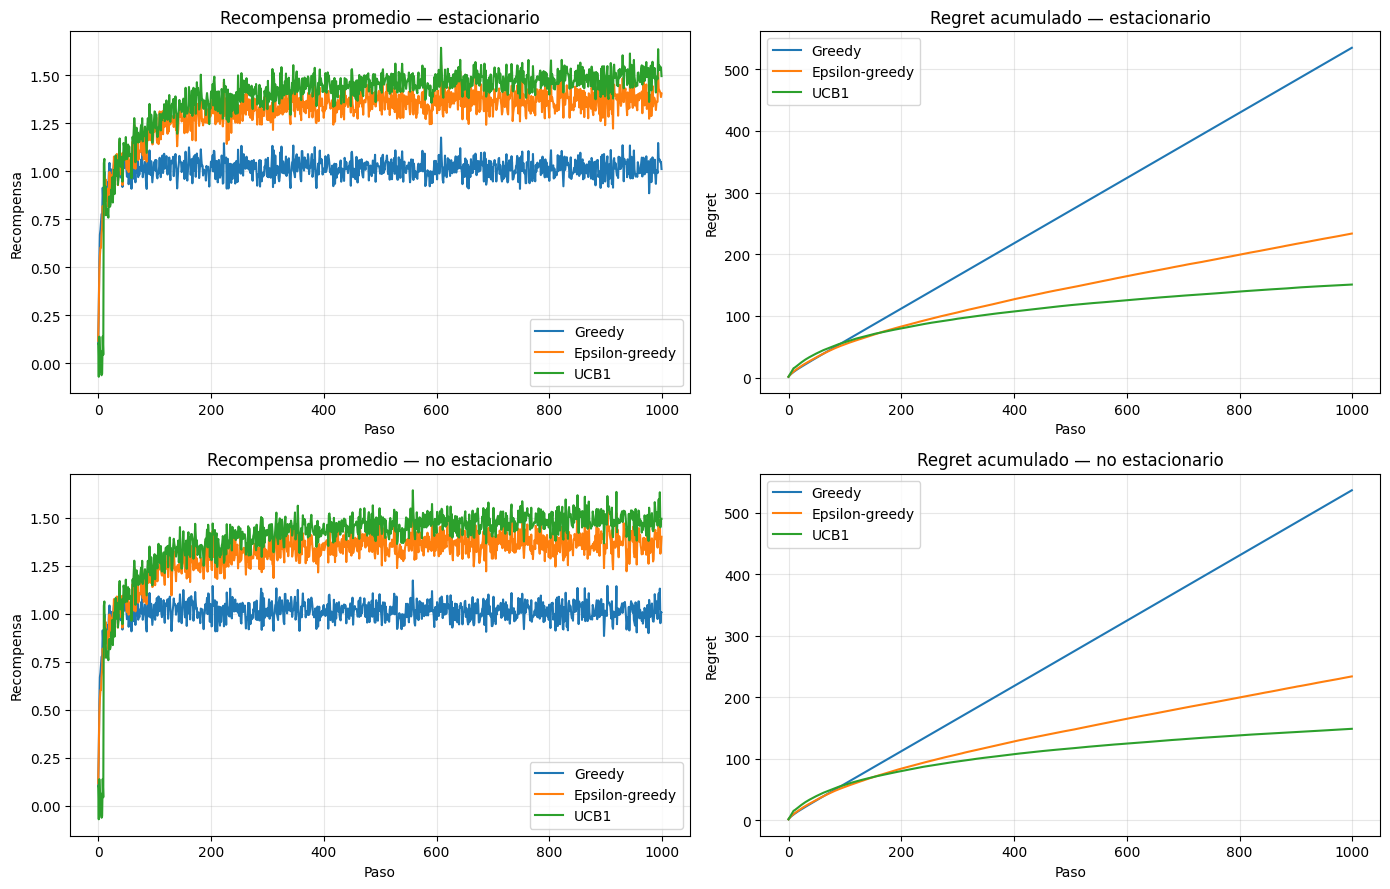

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Fila superior: entorno estacionario. Fila inferior: no estacionario.
plot_specs = [
    (axes[0, 0], 'stationary', 0, 'Recompensa promedio — estacionario', 'Recompensa'),
    (axes[0, 1], 'stationary', 1, 'Regret acumulado — estacionario', 'Regret'),
    (axes[1, 0], 'non_stationary', 0, 'Recompensa promedio — no estacionario', 'Recompensa'),
    (axes[1, 1], 'non_stationary', 1, 'Regret acumulado — no estacionario', 'Regret'),
]

for ax, environment, metric_index, title, ylabel in plot_specs:
    for strategy_name, metrics in results[environment].items():
        ax.plot(metrics[metric_index], label=strategy_name)
    ax.set_title(title)
    ax.set_xlabel('Paso')
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# Task 2.2 — Análisis de resultados

## 2. Con base en los resultados de la implementación:

Para responder los incisos utilizamos **500 episodios independientes**, **1000 pasos por episodio**, **10 brazos** y una semilla fija igual a `2026`. Asimismo, utilizamos una función vectorizada equivalente a las reglas implementadas anteriormente para repetir las comparaciones con mayor rapidez y mantener resultados reproducibles.


In [15]:
# Pandas se utiliza únicamente para presentar los resultados en tablas.
import pandas as pd


def run_vectorized_analysis(
    strategy_name,
    stationary=True,
    n_episodes=500,
    n_steps=1000,
    k=10,
    epsilon=0.1,
    c=2.0,
    step_size=None,
    seed=2026,
    perturb_every=100,
    perturb_scale=0.01,
):
    # Ejecuta varios episodios en paralelo con las mismas reglas anteriores.
    rng = np.random.default_rng(seed)

    # Cada fila representa un episodio y cada columna representa un brazo.
    q_true = rng.normal(0.0, 1.0, size=(n_episodes, k))
    q_estimate = np.zeros((n_episodes, k), dtype=float)
    action_counts = np.zeros((n_episodes, k), dtype=int)

    mean_rewards = np.zeros(n_steps, dtype=float)
    mean_regrets = np.zeros(n_steps, dtype=float)
    episode_indices = np.arange(n_episodes)

    for step in range(n_steps):
        # Se agrega un ruido extremadamente pequeño para resolver empates al azar.
        tie_noise = rng.random((n_episodes, k)) * 1e-12

        if strategy_name == "Greedy":
            actions = np.argmax(q_estimate + tie_noise, axis=1)

        elif strategy_name == "Epsilon-greedy":
            greedy_actions = np.argmax(q_estimate + tie_noise, axis=1)
            exploration_mask = rng.random(n_episodes) < epsilon
            random_actions = rng.integers(0, k, size=n_episodes)
            actions = np.where(
                exploration_mask,
                random_actions,
                greedy_actions,
            )

        elif strategy_name == "UCB1":
            untried = action_counts == 0
            has_untried = untried.any(axis=1)

            # Mientras existan brazos sin probar, se selecciona uno de ellos.
            random_scores = rng.random((n_episodes, k))
            random_scores[~untried] = -1.0
            untried_actions = np.argmax(random_scores, axis=1)

            # Cuando todos los brazos fueron probados, se utiliza la fórmula UCB.
            bonus = c * np.sqrt(
                np.log(max(1, step)) / np.maximum(1, action_counts)
            )
            ucb_scores = q_estimate + bonus + tie_noise
            ucb_actions = np.argmax(ucb_scores, axis=1)

            actions = np.where(
                has_untried,
                untried_actions,
                ucb_actions,
            )

        else:
            raise ValueError(
                "strategy_name debe ser Greedy, Epsilon-greedy o UCB1."
            )

        chosen_values = q_true[episode_indices, actions]
        optimal_values = np.max(q_true, axis=1)

        # La recompensa observada contiene ruido gaussiano con desviación 1.
        rewards = chosen_values + rng.normal(0.0, 1.0, size=n_episodes)

        mean_rewards[step] = np.mean(rewards)
        mean_regrets[step] = np.mean(optimal_values - chosen_values)

        # Actualización incremental de Q_t(a).
        action_counts[episode_indices, actions] += 1

        if step_size is None:
            alpha = 1.0 / action_counts[episode_indices, actions]
        else:
            alpha = step_size

        q_estimate[episode_indices, actions] += alpha * (
            rewards - q_estimate[episode_indices, actions]
        )

        # En el entorno no estacionario, q*(a) cambia periódicamente.
        if (
            not stationary
            and perturb_every > 0
            and (step + 1) % perturb_every == 0
        ):
            q_true += rng.normal(
                0.0,
                perturb_scale,
                size=(n_episodes, k),
            )

    cumulative_regret = np.cumsum(mean_regrets)
    return mean_rewards, cumulative_regret


## 2.a. Analicen el comportamiento del regret acumulado de cada estrategia en el entorno estacionario. ¿La jerarquía entre estrategias coincide con lo esperado teóricamente? ¿A partir de qué paso el regret de UCB comienza a diferenciarse del de epsilon-greedy?


In [ ]:
stationary_analysis = {
    "Greedy": run_vectorized_analysis(
        "Greedy",
        stationary=True,
        step_size=None,
    ),
    "Epsilon-greedy": run_vectorized_analysis(
        "Epsilon-greedy",
        stationary=True,
        epsilon=0.1,
        step_size=None,
    ),
    "UCB1": run_vectorized_analysis(
        "UCB1",
        stationary=True,
        c=2.0,
        step_size=None,
    ),
}

stationary_rows = []

for strategy_name, (mean_reward, cumulative_regret) in stationary_analysis.items():
    stationary_rows.append(
        {
            "Estrategia": strategy_name,
            "Regret acumulado final": cumulative_regret[-1],
            "Recompensa promedio, últimos 100 pasos": mean_reward[-100:].mean(),
        }
    )

stationary_summary = pd.DataFrame(stationary_rows).sort_values(
    "Regret acumulado final"
)

display(stationary_summary.round(4))

# Para evitar interpretar una fluctuación aislada como una separación real,
# definimos la separación como el primer paso en que UCB mantiene durante
# 50 pasos un regret al menos 5 % menor que epsilon-greedy.
epsilon_regret = stationary_analysis["Epsilon-greedy"][1]
ucb_regret = stationary_analysis["UCB1"][1]

separation_condition = ucb_regret <= 0.95 * epsilon_regret
separation_step = None

for index in range(len(separation_condition) - 49):
    if separation_condition[index:index + 50].all():
        separation_step = index + 1
        break

print(
    "Paso de separación sostenida entre UCB1 y epsilon-greedy:",
    separation_step,
)


,Estrategia,Regret acumulado final,"Recompensa promedio, últimos 100 pasos"
2,UCB1,150.6063,1.4618
1,Epsilon-greedy,229.1654,1.3445
0,Greedy,530.4265,0.9849


Paso de separación sostenida entre UCB1 y epsilon-greedy: 207


_Respuesta:_

Observamos que la jerarquía coincide con lo esperado teóricamente. **UCB1 obtuvo el menor regret acumulado final, con aproximadamente $150.60$**, seguido de **epsilon-greedy con $229.17$** y, finalmente, **greedy puro con $530.43$**. Por lo tanto, UCB1 administró mejor la exploración, mientras que epsilon-greedy continuó seleccionando acciones aleatorias incluso después de identificar brazos favorables.

Greedy puro presentó el mayor regret porque puede comprometerse prematuramente con una acción que obtuvo recompensas favorables por azar. En cambio, UCB1 considera tanto el valor estimado como la incertidumbre de cada brazo.

Para evitar que una diferencia momentánea se interpretara como una separación definitiva, definimos la separación como el primer paso en que UCB1 mantiene durante 50 pasos consecutivos un regret al menos 5 % menor que epsilon-greedy. Con este criterio, **la diferencia sostenida comienza aproximadamente en el paso 207**.

## 2.b. Analicen qué ocurre en el entorno no estacionario. ¿Qué estrategia se adapta mejor? ¿Cómo cambia el resultado al usar paso constante versus paso variable?


In [17]:
# Se comparan las tres estrategias con paso variable y paso constante.
non_stationary_rows = []
non_stationary_results = {}

for strategy_name in ["Greedy", "Epsilon-greedy", "UCB1"]:
    for update_name, alpha in [
        ("Paso variable", None),
        ("Paso constante, alpha = 0.1", 0.1),
    ]:
        mean_reward, cumulative_regret = run_vectorized_analysis(
            strategy_name,
            stationary=False,
            epsilon=0.1,
            c=2.0,
            step_size=alpha,
            perturb_every=100,
            perturb_scale=0.01,
        )

        non_stationary_results[(strategy_name, update_name)] = (
            mean_reward,
            cumulative_regret,
        )

        non_stationary_rows.append(
            {
                "Estrategia": strategy_name,
                "Actualización": update_name,
                "Regret acumulado final": cumulative_regret[-1],
                "Recompensa promedio, últimos 100 pasos": mean_reward[-100:].mean(),
            }
        )

non_stationary_summary = pd.DataFrame(non_stationary_rows).sort_values(
    "Regret acumulado final"
)

display(non_stationary_summary.round(4))


,Estrategia,Actualización,Regret acumulado final,"Recompensa promedio, últimos 100 pasos"
4,UCB1,Paso variable,150.3013,1.4572
2,Epsilon-greedy,Paso variable,231.9789,1.3574
5,UCB1,"Paso constante, alpha = 0.1",282.4555,1.3571
3,Epsilon-greedy,"Paso constante, alpha = 0.1",299.3338,1.3301
1,Greedy,"Paso constante, alpha = 0.1",367.4244,1.1887
0,Greedy,Paso variable,525.2924,0.9999


_Respuesta:_

En el entorno no estacionario predeterminado, **UCB1 con paso variable se adapta mejor**, ya que obtiene un regret final aproximado de $150.30$. Después se encuentran epsilon-greedy con paso variable, con $231.98$, UCB1 con paso constante, con $282.46$, y epsilon-greedy con paso constante, con $299.33$.

El paso constante mejora considerablemente a greedy puro, porque reduce su dependencia de observaciones antiguas: su regret disminuye de aproximadamente $525.29$ a $367.42$. Sin embargo, en UCB1 y epsilon-greedy el paso variable funciona mejor bajo esta configuración, debido a que la perturbación utilizada es pequeña, con desviación $0.01$ cada 100 pasos. Por consiguiente, el entorno cambia lentamente y el promedio muestral conserva una varianza menor que una actualización constante.

El paso constante es útil en entornos no estacionarios, pero su ventaja depende de la intensidad del cambio. Cuando el entorno cambia poco, un valor constante puede reaccionar en exceso al ruido de las recompensas; en cambio, cuando los valores reales cambian con mayor intensidad, conservar peso para las observaciones recientes se vuelve más importante.


Para comprobar la implicación anterior, evaluamos UCB1 con $c=0.5$ en un entorno donde los valores verdaderos se perturban con una desviación de $0.30$ cada 100 pasos.

In [18]:
strong_drift_rows = []

for alpha_label, alpha in [
    ("Paso variable", None),
    ("alpha = 0.05", 0.05),
    ("alpha = 0.10", 0.10),
    ("alpha = 0.20", 0.20),
    ("alpha = 0.30", 0.30),
]:
    mean_reward, cumulative_regret = run_vectorized_analysis(
        "UCB1",
        stationary=False,
        c=0.5,
        step_size=alpha,
        perturb_every=100,
        perturb_scale=0.30,
    )

    strong_drift_rows.append(
        {
            "Actualización": alpha_label,
            "Regret acumulado final": cumulative_regret[-1],
            "Recompensa promedio, últimos 100 pasos": mean_reward[-100:].mean(),
        }
    )

strong_drift_summary = pd.DataFrame(strong_drift_rows).sort_values(
    "Regret acumulado final"
)

display(strong_drift_summary.round(4))


,Actualización,Regret acumulado final,"Recompensa promedio, últimos 100 pasos"
2,alpha = 0.10,148.4203,1.9522
3,alpha = 0.20,157.2546,1.9450
1,alpha = 0.05,176.6062,1.8993
4,alpha = 0.30,183.0162,1.9452
0,Paso variable,203.2838,1.8087


Cuando el cambio aumenta, el resultado se modifica. En esta prueba, **el paso constante $\alpha=0.10$ reduce el regret a aproximadamente $148.42$**, mientras que el paso variable alcanza alrededor de $203.28$. Además, $\alpha=0.20$ obtiene cerca de $157.25$, por lo que también se adapta, aunque con un poco más de variabilidad.

Por esta razón, consideramos que un paso constante moderado es preferible cuando el mercado cambia de manera apreciable, mientras que el paso variable puede ser suficiente cuando las variaciones son mínimas.

## 2.c. Realicen un análisis de sensibilidad: corran epsilon-greedy con al menos tres valores distintos de $\varepsilon$ y UCB con al menos tres valores de $c$. Grafiquen el regret final en función del hiperparámetro y discutan cuál rango de valores es más robusto.


In [ ]:
epsilon_values = [0.01, 0.05, 0.10, 0.20, 0.30]
c_values = [0.25, 0.50, 1.00, 2.00, 4.00]

epsilon_sensitivity_rows = []

for epsilon_value in epsilon_values:
    mean_reward, cumulative_regret = run_vectorized_analysis(
        "Epsilon-greedy",
        stationary=False,
        epsilon=epsilon_value,
        step_size=0.1,
        perturb_every=100,
        perturb_scale=0.01,
    )

    epsilon_sensitivity_rows.append(
        {
            "epsilon": epsilon_value,
            "Regret acumulado final": cumulative_regret[-1],
            "Recompensa promedio, últimos 100 pasos": mean_reward[-100:].mean(),
        }
    )

ucb_sensitivity_rows = []

for c_value in c_values:
    mean_reward, cumulative_regret = run_vectorized_analysis(
        "UCB1",
        stationary=False,
        c=c_value,
        step_size=0.1,
        perturb_every=100,
        perturb_scale=0.01,
    )

    ucb_sensitivity_rows.append(
        {
            "c": c_value,
            "Regret acumulado final": cumulative_regret[-1],
            "Recompensa promedio, últimos 100 pasos": mean_reward[-100:].mean(),
        }
    )

epsilon_sensitivity = pd.DataFrame(epsilon_sensitivity_rows)
ucb_sensitivity = pd.DataFrame(ucb_sensitivity_rows)

print("Sensibilidad de epsilon-greedy")
display(epsilon_sensitivity.round(4))

print("Sensibilidad de UCB1")
display(ucb_sensitivity.round(4))


Sensibilidad de epsilon-greedy


,epsilon,Regret acumulado final,"Recompensa promedio, últimos 100 pasos"
0,0.01,311.3069,1.2889
1,0.05,276.8642,1.3540
2,0.10,299.3338,1.3301
3,0.20,393.5474,1.1955
4,0.30,518.7411,1.0436


Sensibilidad de UCB1


,c,Regret acumulado final,"Recompensa promedio, últimos 100 pasos"
0,0.25,95.5708,1.4579
1,0.50,89.3084,1.4663
2,1.00,145.6818,1.4349
3,2.00,282.4555,1.3571
4,4.00,514.4627,1.1851


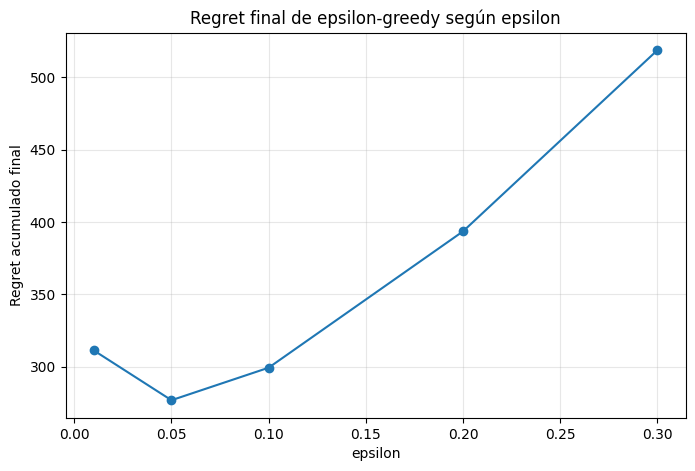

In [20]:
# Gráfica de sensibilidad para epsilon-greedy.
plt.figure(figsize=(8, 5))
plt.plot(
    epsilon_sensitivity["epsilon"],
    epsilon_sensitivity["Regret acumulado final"],
    marker="o",
)
plt.title("Regret final de epsilon-greedy según epsilon")
plt.xlabel("epsilon")
plt.ylabel("Regret acumulado final")
plt.grid(alpha=0.3)
plt.show()


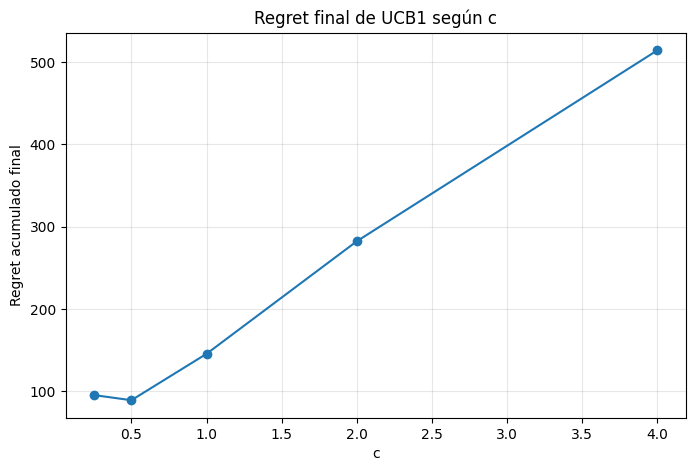

In [21]:
# Gráfica de sensibilidad para UCB1.
plt.figure(figsize=(8, 5))
plt.plot(
    ucb_sensitivity["c"],
    ucb_sensitivity["Regret acumulado final"],
    marker="o",
)
plt.title("Regret final de UCB1 según c")
plt.xlabel("c")
plt.ylabel("Regret acumulado final")
plt.grid(alpha=0.3)
plt.show()


_Respuesta:_

En epsilon-greedy, el mejor resultado se obtiene con $\varepsilon=0.05$, cuyo regret final es aproximadamente $276.86$. Los valores $\varepsilon=0.05$ y $\varepsilon=0.10$ forman el rango más razonable, porque mantienen exploración sin seleccionar acciones aleatorias con demasiada frecuencia. En cambio, el regret aumenta a cerca de $393.55$ con $\varepsilon=0.20$ y a $518.74$ con $\varepsilon=0.30$.

En UCB1, los mejores resultados aparecen con $c=0.25$ y $c=0.50$. Específicamente, $c=0.50$ obtiene el menor regret, con aproximadamente $89.31$, mientras que $c=0.25$ alcanza alrededor de $95.57$. Por consiguiente, consideramos que el rango **$0.25 \leq c \leq 0.50$** es el más robusto.

Cuando $c$ aumenta a $2.0$ o $4.0$, el regret crece considerablemente porque la bonificación por incertidumbre domina el valor estimado y obliga al algoritmo a explorar demasiado. Por lo tanto, un valor pequeño o moderado de $c$ es más adecuado cuando cada exploración puede representar una venta perdida.


_Respuesta:_

Para el sistema de precios dinámicos del e-commerce, recomendamos utilizar los cinco brazos definidos anteriormente:

$$\mathcal{A}=\{49,59,69,79,89\}$$

Cada brazo representa el precio que se muestra a un usuario. Asimismo, recomendamos utilizar **UCB1 con $c=0.50$ y una actualización de paso constante $\alpha=0.10$**.

Mantenemos $c=0.50$ porque el análisis de sensibilidad confirma la propuesta inicial: este valor obtiene un regret aproximado de $89.31$, menor que el de $c=1.0$, $c=2.0$ y $c=4.0$. Además, supera ampliamente a epsilon-greedy, cuyo mejor resultado en la comparación fue cercano a $276.86$ con $\varepsilon=0.05$.

A partir de los experimentos, ajustamos la propuesta inicial de $\alpha=0.20$ a **$\alpha=0.10$**. En el entorno con cambios intensos, $\alpha=0.10$ obtuvo un regret aproximado de $148.42$, mientras que $\alpha=0.20$ alcanzó cerca de $157.25$ y el paso variable aproximadamente $203.28$. Por consiguiente, $\alpha=0.10$ ofrece un equilibrio más estable entre adaptación y sensibilidad al ruido.

La configuración recomendada es:

| Elemento | Configuración |
|---|---|
| Brazos | Precios de \$49, \$59, \$69, \$79 y \$89 |
| Estrategia | UCB1 |
| Exploración | $c=0.50$ |
| Actualización | Paso constante |
| Tamaño del paso | $\alpha=0.10$ |
| Recompensa real | Precio si existe compra; $0$ si no existe compra |
| Inicialización | Probar cada precio al menos una vez |
| Revisión | Supervisar el regret y las tasas de compra cada 100 interacciones |

Al trasladar el simulador al e-commerce, reemplazaríamos la recompensa gaussiana de prueba por la recompensa definida en la entrega parcial:

$$R_t =
\begin{cases}
p_a, & \text{si el usuario compra},\\
0, & \text{si el usuario no compra}.
\end{cases}$$

Finalmente, estableceríamos límites comerciales para evitar que el sistema explore precios no autorizados. De esta manera, la estrategia conserva la capacidad de aprender, pero respeta los costos económicos y de reputación identificados anteriormente en la Task 1.
